In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Ignoring all future warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [166]:
data = pd.read_csv("train.csv")
data.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
242,243,50,RM,63.0,5000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,79000
1335,1336,20,RL,80.0,9650,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,167900
427,428,20,RL,77.0,8593,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,109008
911,912,20,RL,NaN,9286,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,143500
105,106,60,FV,75.0,9375,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2008,WD,Normal,250000


In [167]:
cat_cols = data.select_dtypes(["object"]).columns
cat_cols, len(cat_cols)

(Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
        'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
        'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
        'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
        'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
        'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
        'SaleType', 'SaleCondition'],
       dtype='object'),
 43)

In [168]:
data["SalePrice"] = np.log(data["SalePrice"])

<Axes: >

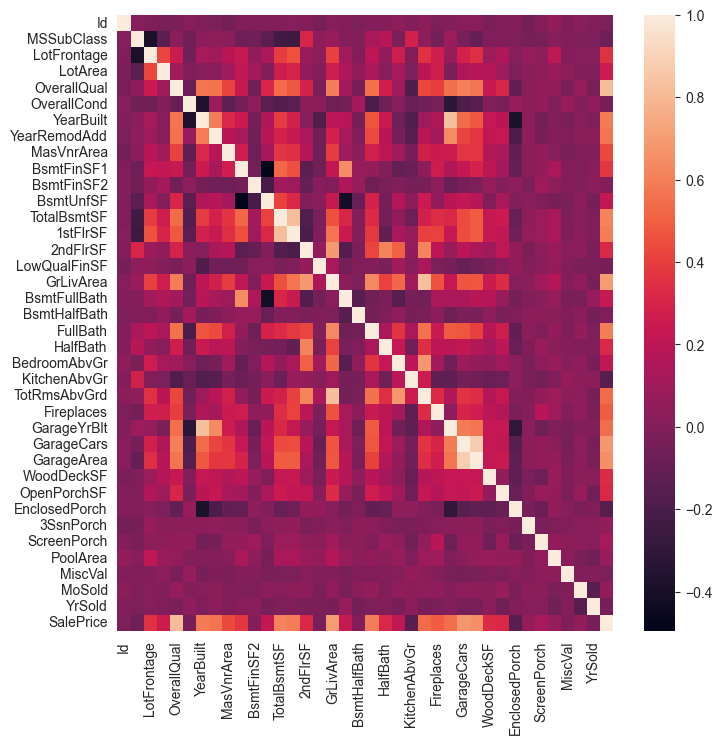

In [169]:
plt.figure(figsize = (8,8))
sns.heatmap(data = data.select_dtypes(exclude = ["object"]).corr("pearson"))

In [170]:
skewed_feature = ["LotFrontage","LotArea","GrLivArea","1stFlrSF"]
data[skewed_feature] = np.log(data[skewed_feature]+1)

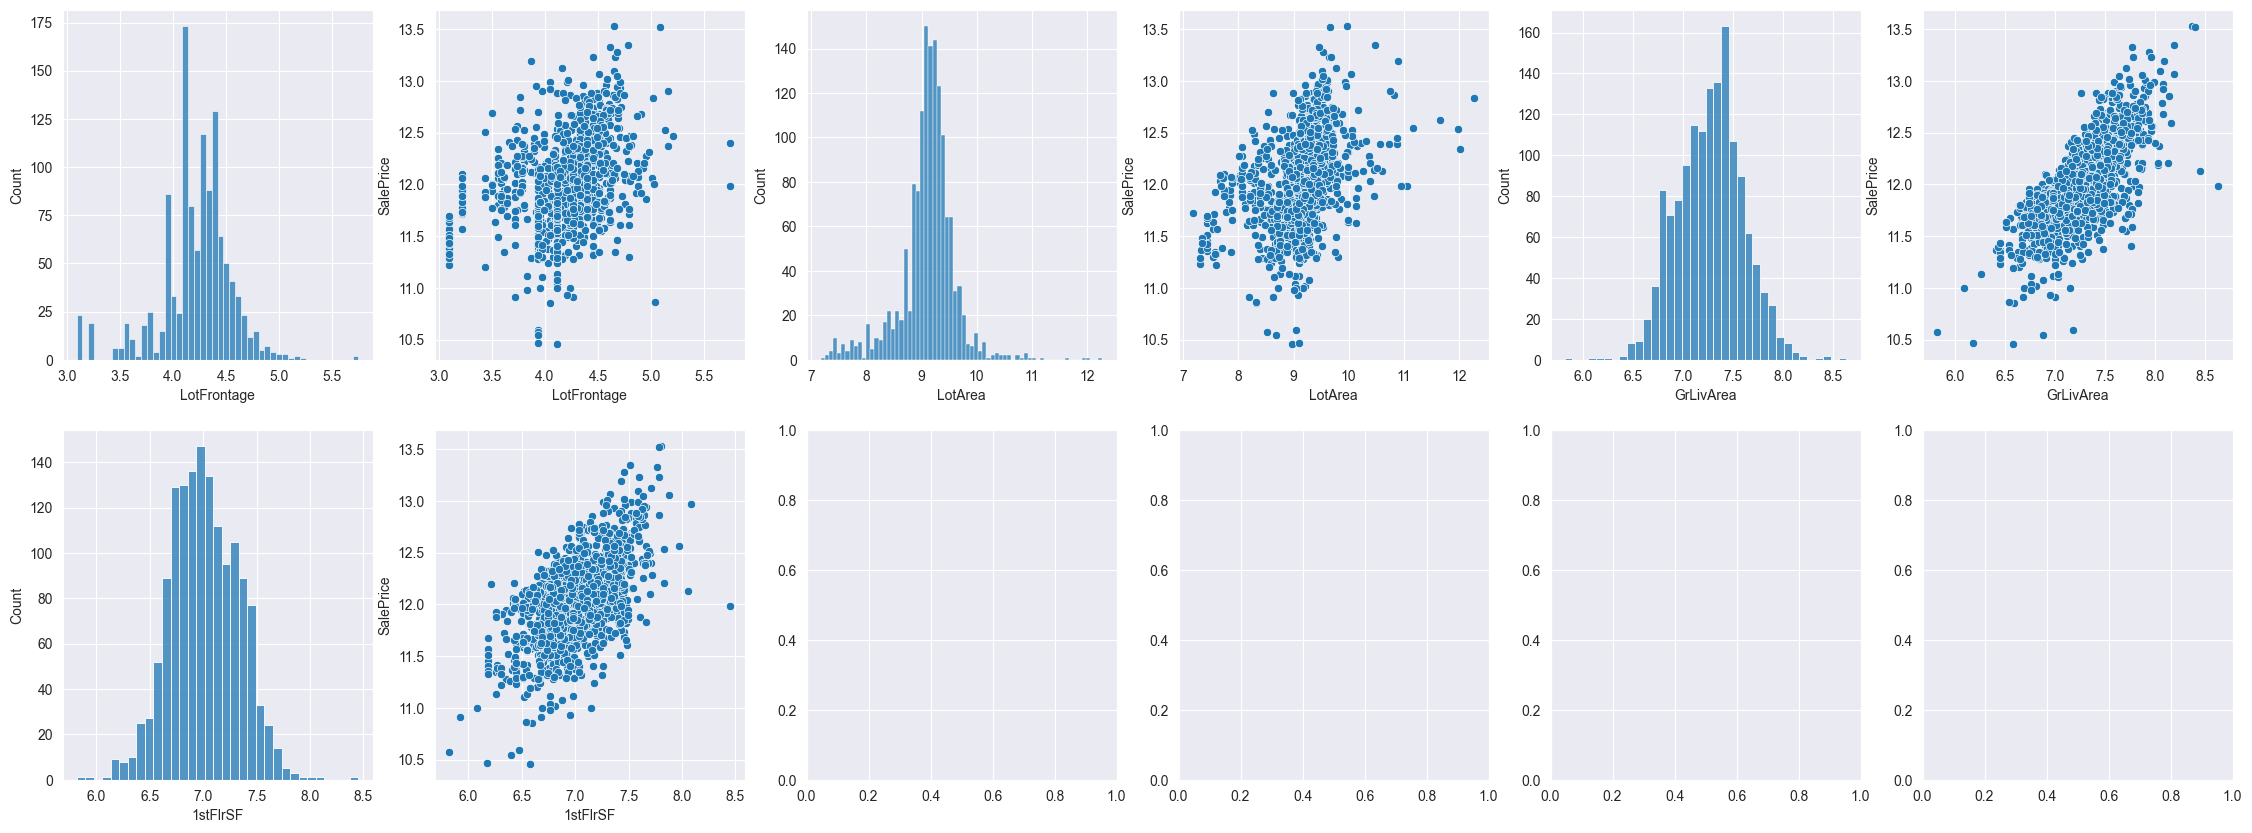

In [171]:
fig, axes = plt.subplots((2*len(skewed_feature) + 6 - 1) // 6 ,6, figsize = (28,10))

axes = axes.flatten()

for cat in range(len(skewed_feature)):
    if cat >= len(skewed_feature):
        axes[cat*2].set_visible(False)
        axes[cat*2+1].set_visible(False)
        continue
    sns.histplot(x = skewed_feature[cat],  data = data, ax = axes[cat*2])
    sns.scatterplot(x = skewed_feature[cat],y = "SalePrice",  data = data, ax = axes[cat*2+1])

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

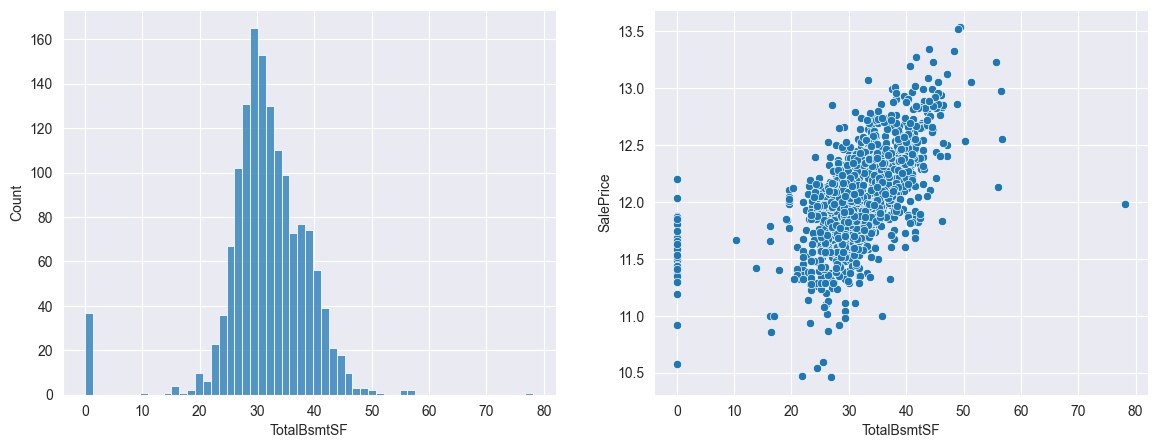

In [172]:
data["TotalBsmtSF"] = data["TotalBsmtSF"]**0.5
fig, axes = plt.subplots(1,2,figsize = (14,5))
axes = axes.flatten()
sns.histplot(x = "TotalBsmtSF",  data = data, ax = axes[0])
sns.scatterplot(x = "TotalBsmtSF",y = "SalePrice",  data = data, ax = axes[1])

In [173]:
data.drop(columns = 'Id', inplace = True)
data.sample(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
544,60,RL,4.077537,9.747126,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2006,New,Partial,12.098849
964,60,RL,4.394449,9.334061,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2010,WD,Normal,12.277928
221,60,RL,NaN,8.995785,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,12,2009,ConLI,Normal,12.206073
982,20,RL,3.784190,8.065579,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,11.982273
264,30,RM,3.433987,8.562740,Pave,Grvl,IR3,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,11.198215


<Axes: xlabel='HasSecondFloor', ylabel='SalePrice'>

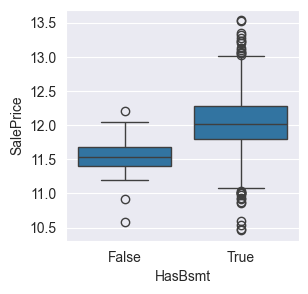

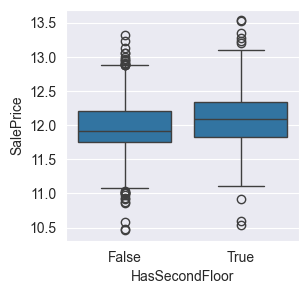

In [174]:
data["HasBsmt"] = data["TotalBsmtSF"] > 0
plt.figure(figsize = (3,3))
sns.boxplot(x = "HasBsmt", y = "SalePrice", data = data)
data["HasSecondFloor"] = data["2ndFlrSF"] > 0
plt.figure(figsize = (3,3))
sns.boxplot(x = "HasSecondFloor", y = "SalePrice", data = data)

In [175]:
columns_with_na = data.columns[data.isna().sum() > 0]
print(data[columns_with_na].isna().sum()/len(data[columns_with_na[0]]))

LotFrontage     0.177397
Alley           0.937671
MasVnrType      0.597260
MasVnrArea      0.005479
BsmtQual        0.025342
BsmtCond        0.025342
BsmtExposure    0.026027
BsmtFinType1    0.025342
BsmtFinType2    0.026027
Electrical      0.000685
FireplaceQu     0.472603
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
GarageQual      0.055479
GarageCond      0.055479
PoolQC          0.995205
Fence           0.807534
MiscFeature     0.963014
dtype: float64


In [176]:
fill_0 = ["GarageYrBlt","GarageQual","GarageCond","MasVnrArea","BsmtQual","BsmtCond","PoolQC"]
fill_missing = ["GarageFinish","GarageType","Alley","MasVnrType","MiscFeature"]
data[fill_0] = data[fill_0].fillna(0)
data[fill_missing] = data[fill_missing].fillna("missing")
data["LotFrontage"].fillna(data["LotFrontage"].median(), inplace = True)
data["PoolQC"].map({0:0,'Ex':3,'Fa':1,'Gd':0})
data["PoolArea"] *= data["PoolQC"]
data.drop(columns = "PoolQC", inplace = True)
data["Electrical"].fillna(data["Electrical"].mode(), inplace = True)
data["TotalBathroom"] = data["FullBath"] + data["BsmtFullBath"] + 0.5*data["HalfBath"]+0.5*data["BsmtHalfBath"]